##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class**

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [8]:
!pip install tensorflow tensorflow_hub opencv-python matplotlib

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [9]:
import kagglehub

# Download latest version
path = kagglehub.model_download("tensorflow/mask-rcnn-inception-resnet-v2/tensorFlow2/1024x1024")

print("Path to model files:", path)

model = tf.saved_model.load(path)

Path to model files: /kaggle/input/mask-rcnn-inception-resnet-v2/tensorflow2/1024x1024/1


In [28]:
from google.colab import files
uploaded = files.upload()
image_paths = list(uploaded.keys())

def load_image(path):
    img = cv2.imread(path)

    if img is None:
        print(f" Error: Could not load image at {path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img
images = [load_image(p) for p in image_paths]

Saving  -9.jpg to  -9 (2).jpg
Saving  -12 copy 2.jpg to  -12 copy 2 (1).jpg
Saving  -12.jpg to  -12 (1).jpg
Saving Chicago Highways.jpg to Chicago Highways (1).jpg
Saving Coffee ☕️.jpg to Coffee ☕️ (1).jpg
Saving Fresh bananas apples and oranges in a bowl isolated on transparent background Stock Photo.jpg to Fresh bananas apples and oranges in a bowl isolated on transparent background Stock Photo.jpg
Saving Prietenii.jpg to Prietenii.jpg


In [29]:
def run_inference(image):
    input_tensor = tf.convert_to_tensor(image)
    input_tensor = input_tensor[tf.newaxis, ...]  # add batch dimension

    outputs = model.signatures['serving_default'](input_tensor)
    return outputs

results = [run_inference(img) for img in images]

In [36]:
def extract_results(result):
    boxes = result['detection_boxes'][0].numpy()
    #classes = result['detection_classes'][0].numpy().astype(int)
    classes = result['detection_classes'][0].numpy().astype(np.int32)
    scores = result['detection_scores'][0].numpy()
    masks = result['detection_masks'][0].numpy()

    return boxes, classes, scores, masks

In [37]:
COCO_CLASSES = [
    "BG","person","bicycle","car","motorcycle","airplane","bus","train","truck",
    "boat","traffic light","fire hydrant","stop sign","parking meter","bench",
    "bird","cat","dog","horse","sheep","cow","elephant","bear","zebra","giraffe",
    "backpack","umbrella","handbag","tie","suitcase","frisbee","skis","snowboard",
    "sports ball","kite","baseball bat","baseball glove","skateboard","surfboard",
    "tennis racket","bottle","wine glass","cup","fork","knife","spoon","bowl",
    "banana","apple","sandwich","orange","broccoli","carrot","hot dog","pizza",
    "donut","cake","chair","couch","potted plant","bed","dining table","toilet",
    "tv","laptop","mouse","remote","keyboard","cell phone","microwave","oven",
    "toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear",
    "hair drier","toothbrush"
]

In [38]:
def visualize(image, boxes, classes, scores, masks, threshold=0.5):
    h, w, _ = image.shape

    for i in range(len(scores)):
        if scores[i] < threshold:
            continue

        # Bounding box
        y1, x1, y2, x2 = boxes[i]
        y1, x1, y2, x2 = int(y1*h), int(x1*w), int(y2*h), int(x2*w)


        #label = COCO_CLASSES[classes[i]]
        class_id = int(classes[i])

        if class_id < 0 or class_id >= len(COCO_CLASSES):
            continue  # skip invalid class

        label = COCO_CLASSES[class_id]
        score = scores[i]

        # Draw box
        cv2.rectangle(image, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(image, f"{label}: {score:.2f}",
                    (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255,0,0), 2)

        # Fixed mask
        mask = masks[i]

        # Resize mask to bounding box size ONLY
        mask = cv2.resize(mask, (x2 - x1, y2 - y1))
        mask = (mask > 0.5)

        # Extract ROI
        roi = image[y1:y2, x1:x2]

        # Apply mask only inside ROI
        roi[mask] = roi[mask] * 0.5 + np.array([0,255,0]) * 0.5

        # Put back ROI
        image[y1:y2, x1:x2] = roi

    plt.imshow(image)
    plt.axis('off')
    plt.show()

{np.int32(1), np.int32(3), np.int32(16), np.int32(17), np.int32(18), np.int32(31), np.int32(37), np.int32(44), np.int32(47), np.int32(48), np.int32(49), np.int32(50), np.int32(51), np.int32(53), np.int32(61), np.int32(62), np.int32(63), np.int32(67), np.int32(73), np.int32(74), np.int32(75), np.int32(76), np.int32(77), np.int32(79), np.int32(84), np.int32(85), np.int32(86), np.int32(87), np.int32(89), np.int32(90)}


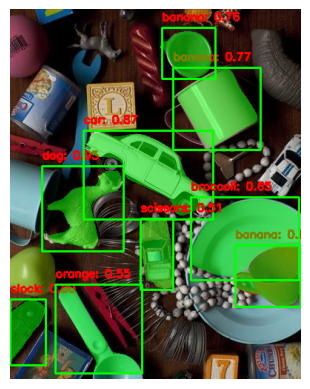

{np.int32(1), np.int32(9), np.int32(15), np.int32(17), np.int32(19), np.int32(27), np.int32(28), np.int32(31), np.int32(32), np.int32(40), np.int32(42), np.int32(43), np.int32(62), np.int32(63), np.int32(64), np.int32(65), np.int32(67), np.int32(70), np.int32(77), np.int32(79), np.int32(81), np.int32(82), np.int32(85), np.int32(87)}


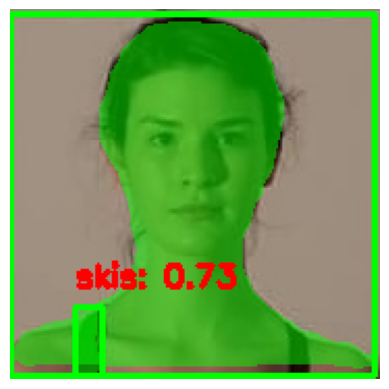

{np.int32(1), np.int32(2), np.int32(3), np.int32(9), np.int32(15), np.int32(17), np.int32(19), np.int32(21), np.int32(27), np.int32(28), np.int32(31), np.int32(32), np.int32(33), np.int32(40), np.int32(42), np.int32(62), np.int32(63), np.int32(64), np.int32(65), np.int32(67), np.int32(70), np.int32(81), np.int32(82)}


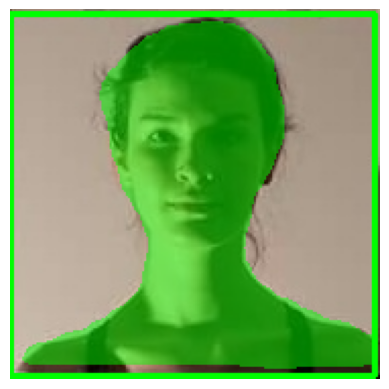

{np.int32(1), np.int32(3), np.int32(8), np.int32(9), np.int32(20), np.int32(21)}


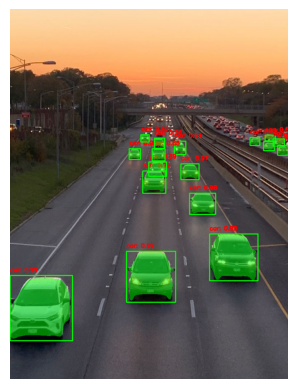

{np.int32(67), np.int32(70), np.int32(44), np.int32(46), np.int32(79), np.int32(47), np.int32(81), np.int32(50), np.int32(51), np.int32(86), np.int32(57), np.int32(61)}


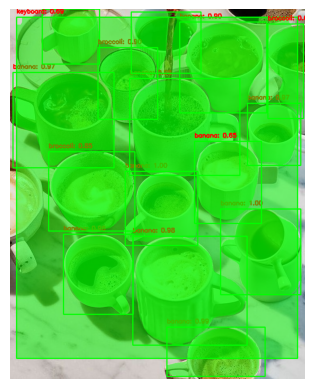

{np.int32(64), np.int32(1), np.int32(65), np.int32(67), np.int32(47), np.int32(79), np.int32(81), np.int32(15), np.int32(51), np.int32(52), np.int32(53), np.int32(84), np.int32(55), np.int32(56), np.int32(57), np.int32(86), np.int32(60), np.int32(62)}


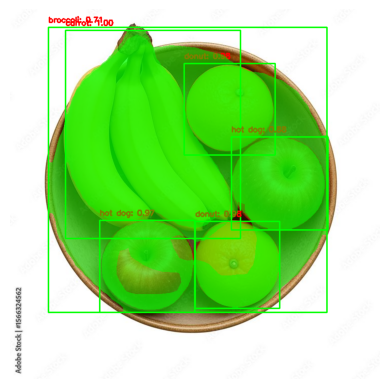

{np.int32(1), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(24), np.int32(25), np.int32(31), np.int32(47), np.int32(50), np.int32(51), np.int32(62), np.int32(64), np.int32(67), np.int32(86)}


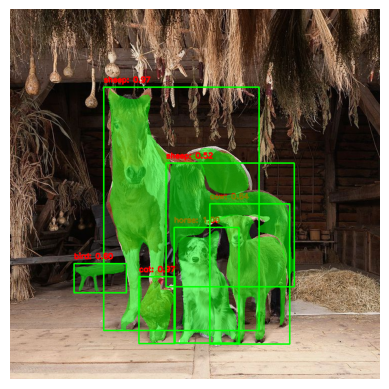

In [39]:
for img, res in zip(images, results):
    boxes, classes, scores, masks = extract_results(res)
    print(set(classes))
    visualize(img.copy(), boxes, classes, scores, masks, threshold=0.5)

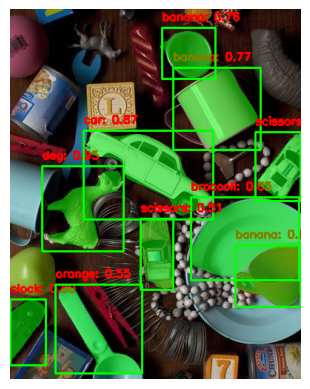

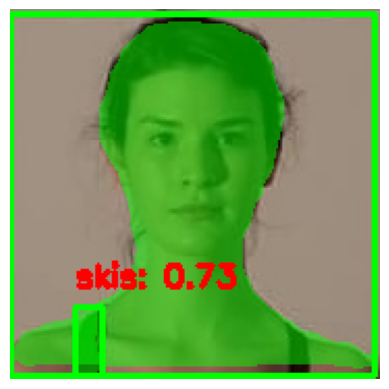

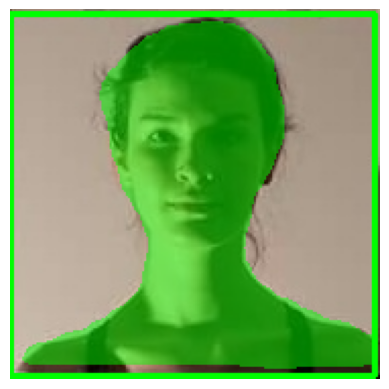

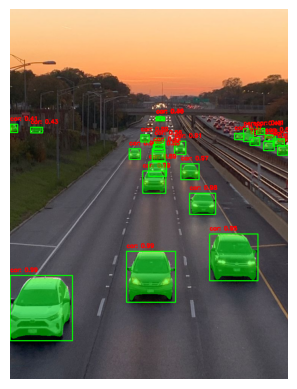

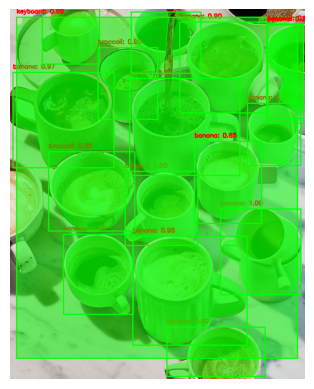

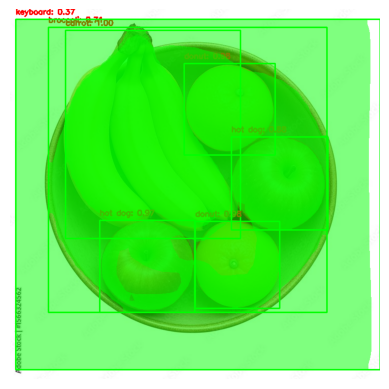

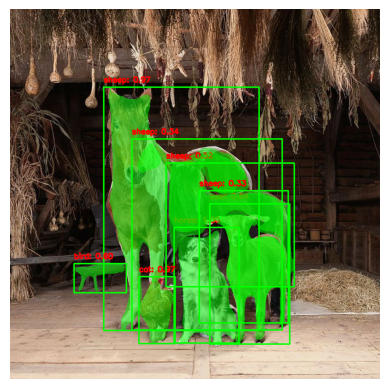

In [40]:
for img, res in zip(images, results):
    boxes, classes, scores, masks = extract_results(res)
    visualize(img.copy(), boxes, classes, scores, masks, threshold=0.3)